## Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

In [ ]:
app = pd.read_csv('../datasets/cleaned_apps.csv')

In [34]:
print('Statistics for numeric columns in App Dataset')
app.agg({'Rating':['count','min', 'max','mean','std'], 'Reviews':['count','min', 'max','mean','std'], 'Installs':['count','min', 'max','mean','std'], 'Price':['count','min', 'max','mean','std']}).round(2)

Statistics for numeric columns in App Dataset


,Rating,Reviews,Installs,Price
count,8196.00,8196.00,8.196000e+03,8196.00
min,1.00,1.00,1.000000e+00,0.00
max,5.00,78158306.00,1.000000e+09,400.00
mean,4.17,255248.35,9.168273e+06,1.04
std,0.54,1985679.00,5.825270e+07,16.86


In [36]:
sns.set_theme(style="whitegrid")

## EDA ON APP DATASET

### UNIVARIATE ANALYSIS
Most popular category is Family.

Most of the apps are free.

Most apps have ratings lying in the range 4.0 - 4.5.

The analysis indicates most apps serve 'Everyone' rather than a specific age range.

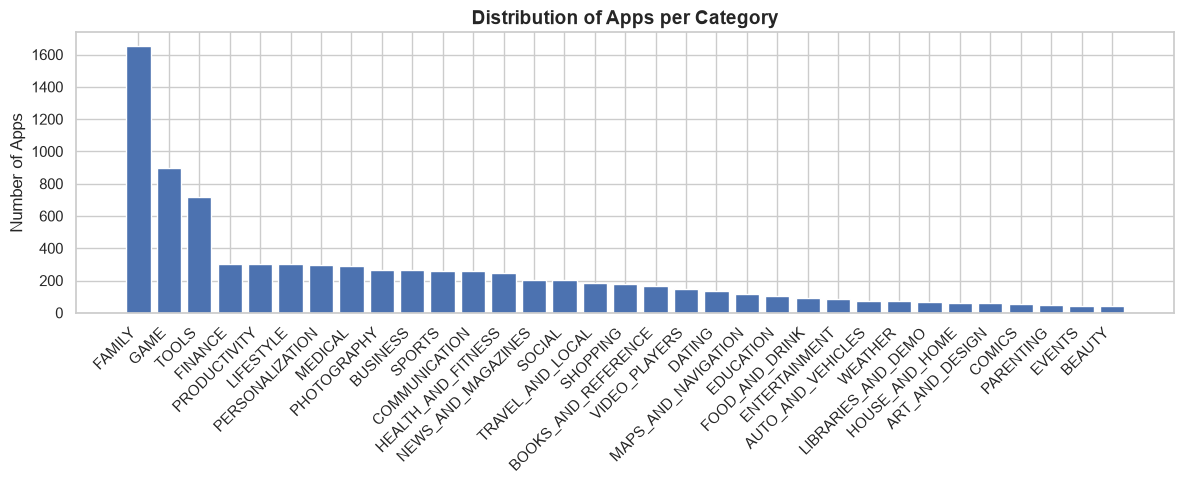

In [37]:
# CATEGORY
plt.figure(figsize=(12,5))

counts = app['Category'].value_counts()

plt.bar(counts.index, counts.values)

plt.ylabel('Number of Apps')

plt.title('Distribution of Apps per Category', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

BAR GRAPH ON CATEGORY

Family Category leads in the categories section with more 1600 apps serving this category.

Beauty is the least popular category.

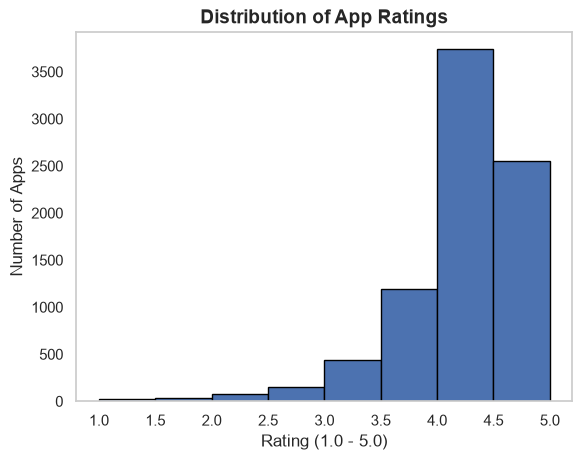

In [38]:
# Distribution of App Ratings histogram
plt.hist(app['Rating'], bins=8, edgecolor='black')
plt.grid(False)
plt.title('Distribution of App Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating (1.0 - 5.0)')
plt.ylabel('Number of Apps')
plt.show()

HISTOGRAM FOR DISTRIBUTION OF APP RATINGS

Most of the apps have ratings in the range 4.0 - 4.5.

Text(0.5, 1.0, 'Distribution of Ratings per Apps')

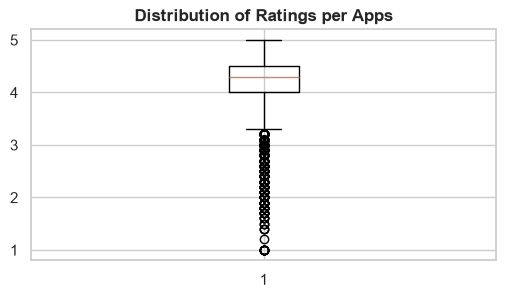

In [39]:
# Boxplot for Ratings Distribution
plt.figure(figsize=[6,3])
plt.boxplot(app['Rating'])
plt.title('Distribution of Ratings per Apps', fontweight='bold')


BOXPLOT ON RATINGS

50% of the apps have ratings lying in the range 4.0 - 4.5.

Half the apps are rated higher than 4.3 and half are rated lower than 4.3.

Only 25% of apps have ratings lower than 4.0.

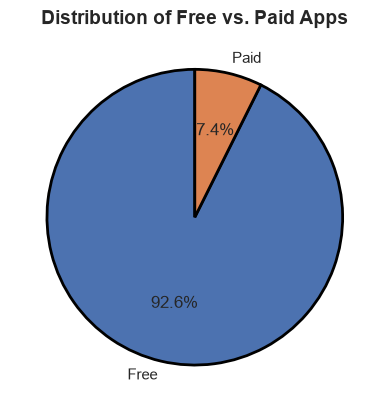

In [40]:
# Distribution on type of apps

type_counts = app['Type'].value_counts()
plt.pie(type_counts, 
        labels=type_counts.index, 
        autopct='%1.1f%%',       
        startangle=90,           
        wedgeprops={'edgecolor': 'black', 'linewidth': 2}) 

plt.title('Distribution of Free vs. Paid Apps', fontsize=14, fontweight='bold')
plt.show()

PIE CHART DEMONSTRATING THE BREAKDOWN BETWEEN FREE AND PAID APPS

Most of the apps (more than 92%) are free apps.

<Axes: title={'center': 'Distribution of Apps per Content Rating'}, ylabel='Content Rating'>

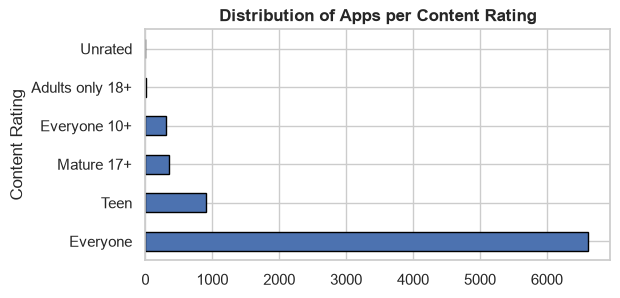

In [41]:
#Content Rating
plt.title('Distribution of Apps per Content Rating', fontweight='bold')
plt.ylabel('Distribution of apps')
app['Content Rating'].value_counts().plot(kind='barh', edgecolor='black', figsize=[6,3])

BAR GRAPH ON DISTRIBUTION OF APPS PER CONTENT RATING

More than 6000 apps have content rating Everyone overpowering the other content ratings by a significant margin.

### BIVARIATE ANALYSIS

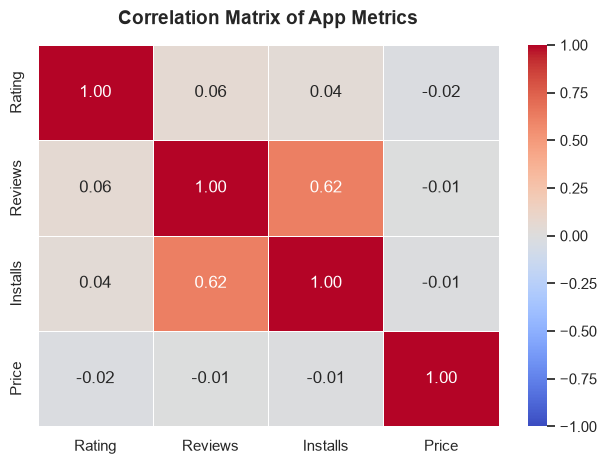

In [42]:
# heatmap to find correlation among apps and metrics
corr_matrix=app[['Rating', 'Reviews', 'Installs', 'Price']].corr()

sns.heatmap(
    corr_matrix,   
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    linewidths=0.5,      
    vmin=-1, vmax=1    
)

plt.title('Correlation Matrix of App Metrics', fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

Heat Map showing relationship between distribution of apps and various numeric metrics

The only significant relationship exists between Installs & Reviews.
As an app gets more installations, it naturally accumulates significantly more reviews (or vice-versa). They move upward together.

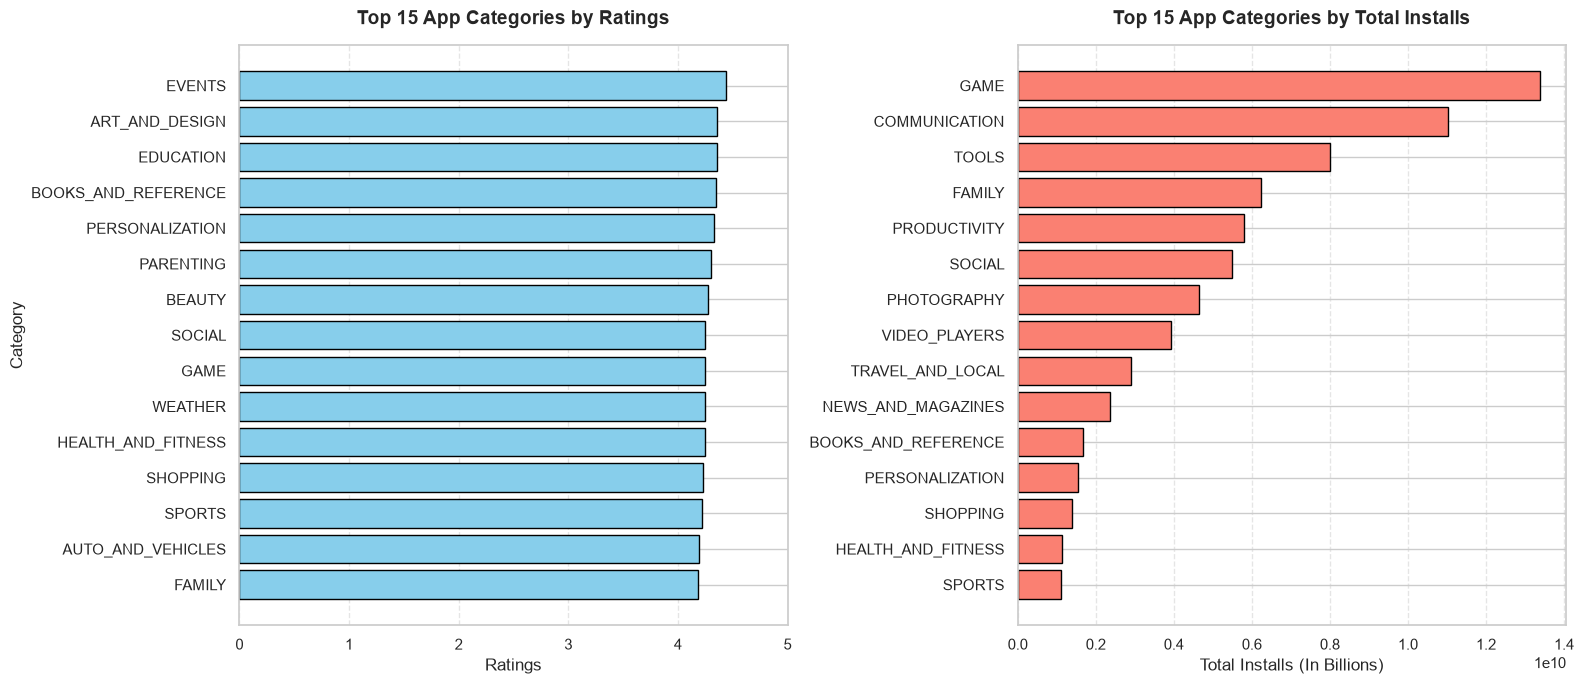

In [46]:
import matplotlib.pyplot as plt

# 1. Prepare the data for both graphs
top_ratings = app.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(15)[::-1]
top_installs = app.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(15)[::-1]

# 2. Setup the canvas with 1 row and 2 columns (side-by-side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')

# --- LEFT GRAPH: Average Ratings (ax1) ---
ax1.barh(top_ratings.index, top_ratings.values, edgecolor='black', color='skyblue')
ax1.grid(axis='x', linestyle='--', alpha=0.5)
ax1.set_title('Top 15 App Categories by Ratings', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Ratings', fontsize=12)
ax1.set_ylabel('Category', fontsize=12)
ax1.set_xlim(0, 5) # Keeps the rating scale relative to 5 stars

# --- RIGHT GRAPH: Total Installs (ax2) ---
ax2.barh(top_installs.index, top_installs.values, edgecolor='black', color='salmon')
ax2.grid(axis='x', linestyle='--', alpha=0.5)
ax2.set_title('Top 15 App Categories by Total Installs', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Total Installs (In Billions)', fontsize=12)
# We can skip the y-label here because it shares the same categories as the left side!

# 3. Clean up margins so nothing overlaps or gets cut off
plt.tight_layout()

plt.show()

Apps serving the 'Events' category have the highest Average Rating, which could be driven by the fact that it has the second lowest distribution of apps serving this category.

Meanwhile 'Family' category, which we found has the most number of apps, has the lowest average rating, which could be driven by the large distribution of apps serving this category.

So this might not be the most reliable distribution and we should create a scatter chart instead which considers the number of installs along with the rating received for a category.

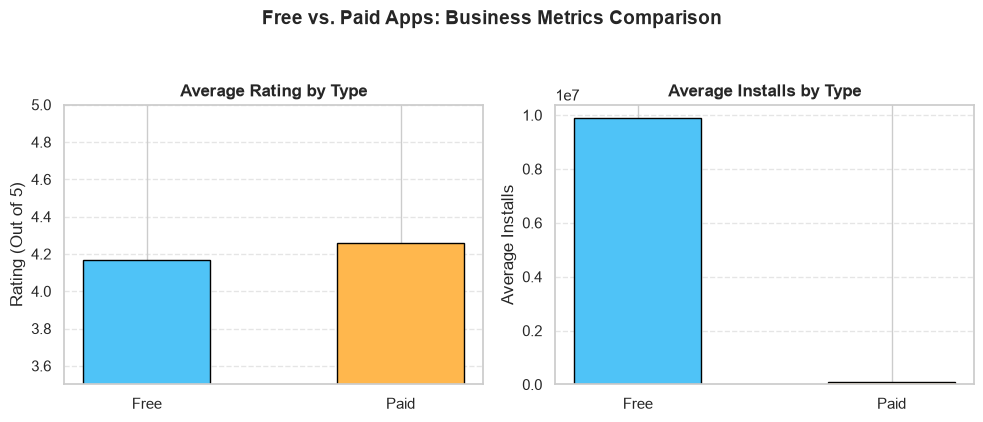

In [85]:
import matplotlib.pyplot as plt

# 1. Calculate the averages
type_metrics = app.groupby('Type')[['Rating', 'Installs']].mean()

# 2. Set up side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Chart 1: Average Rating by Type ---
ax1.bar(type_metrics.index, type_metrics['Rating'], color=['#4fc3f7', '#ffb74d'], edgecolor='black', width=0.5)
ax1.set_ylim(3.5, 5.0)  # Zoom in to see the subtle rating differences
ax1.set_title('Average Rating by Type', fontsize=12, fontweight='bold')
ax1.set_ylabel('Rating (Out of 5)')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Chart 2: Average Installs by Type ---
ax2.bar(type_metrics.index, type_metrics['Installs'], color=['#4fc3f7', '#ffb74d'], edgecolor='black', width=0.5)
ax2.set_title('Average Installs by Type', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Installs')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Free vs. Paid Apps: Business Metrics Comparison', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### MULTIVARIATE ANALYSIS

In [87]:
app.pivot_table(
    values='Rating',
    index='Category',
    columns='Content Rating'
).round(2)

Content Rating,Adults only 18+,Everyone,Everyone 10+,Mature 17+,Teen,Unrated
Category,,,,,,
ART_AND_DESIGN,NaN,4.35,4.70,NaN,4.47,NaN
AUTO_AND_VEHICLES,NaN,4.19,4.30,NaN,4.20,NaN
BEAUTY,NaN,4.29,NaN,4.50,4.00,NaN
BOOKS_AND_REFERENCE,NaN,4.35,4.47,4.17,4.29,NaN
BUSINESS,NaN,4.10,NaN,NaN,4.30,NaN
COMICS,4.2,4.34,4.45,3.87,4.04,NaN
COMMUNICATION,NaN,4.10,NaN,4.29,4.29,NaN
DATING,NaN,3.90,NaN,3.97,3.97,NaN
EDUCATION,NaN,4.35,4.60,4.17,4.80,NaN


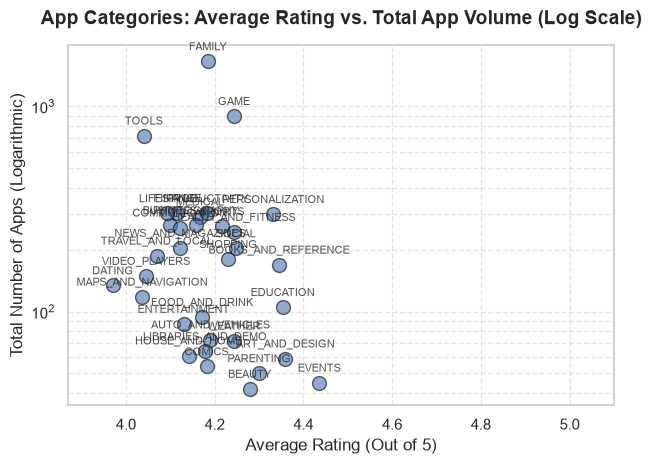

In [88]:
import matplotlib.pyplot as plt

cat_data = app.groupby('Category')['Rating'].agg(['count', 'mean'])

plt.scatter(
    cat_data['mean'], 
    cat_data['count'], 
    alpha=0.6, 
    edgecolors='black', 
    s=100
)

# --- THIS IS THE MAGIC LINE ---
plt.yscale('log') 

for category, row in cat_data.iterrows():
    plt.annotate(
        category, 
        (row['mean'], row['count']),
        textcoords="offset points", 
        xytext=(0, 8), 
        ha='center', 
        fontsize=8, 
        alpha=0.8
    )

plt.xlim(cat_data['mean'].min() - 0.1, 5.1)
plt.grid(True, linestyle='--', alpha=0.5, which="both") # "both" grids major & minor log lines

plt.title('App Categories: Average Rating vs. Total App Volume (Log Scale)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Rating (Out of 5)', fontsize=12)
plt.ylabel('Total Number of Apps (Logarithmic)', fontsize=12)

plt.tight_layout()
plt.show()

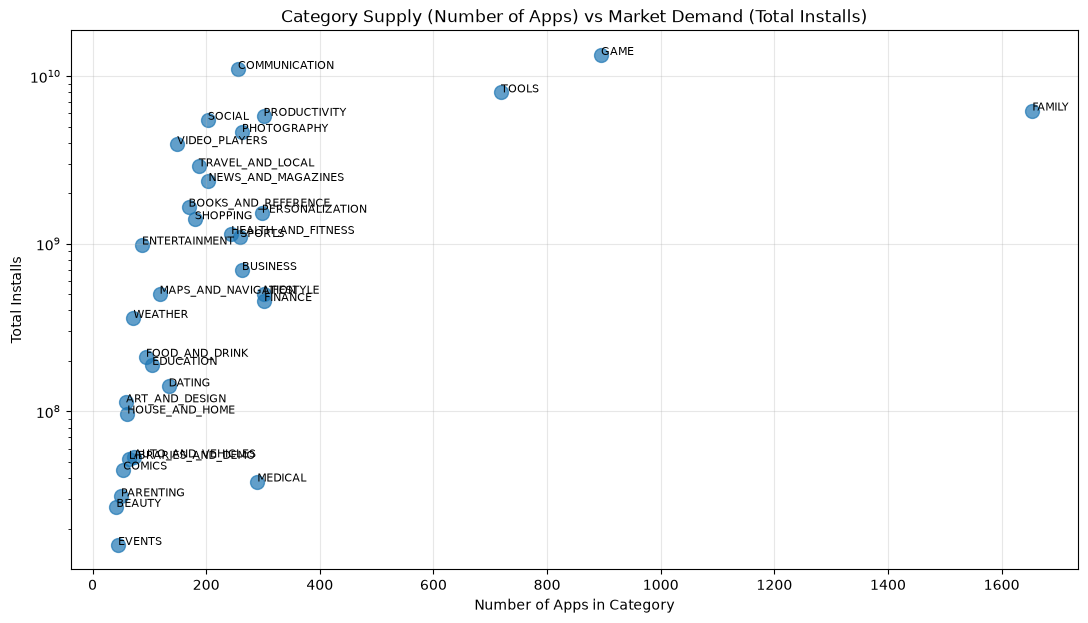

In [ ]:
# scatter plot with Installs and Count of apps for each category and dots showing categories to see if the category which is most served is the most installed or is there an underserved market category with high installs

import matplotlib.pyplot as plt

# Create summary table
category_summary = (
    app.groupby('Category')
      .agg(
          App_Count=('App', 'count'),
          Total_Installs=('Installs', 'sum')
      )
      .reset_index()
)

# Scatter plot
plt.figure(figsize=(13,7))

plt.scatter(
    category_summary['App_Count'],
    category_summary['Total_Installs'],
    s=100,
    alpha=0.7
)

# Add category labels
for _, row in category_summary.iterrows():
    plt.text(
        row['App_Count'],
        row['Total_Installs'],
        row['Category'],
        fontsize=8
    )

plt.xlabel('Number of Apps in Category')
plt.ylabel('Total Installs')
plt.title('Category Supply (Number of Apps) vs Market Demand (Total Installs)')
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

The category with high installs and less number of apps is an underserved market with high demand. So new apps for 'Communication', 'Social', 'Photography', 'Productivity' etc can really breakout and be successful, instead of new apps being developed to serve a saturated market like 'Family'.